# RSVP Semantic Flow and Information Geometry Notebook

This notebook explores **semantic flows** in parameter space and representation space,
using information-geometric diagnostics:

- KL divergence between predictive distributions along training
- Fisher information approximations via gradient covariances
- Comparison of plain vs. lamphrodynamically-regularized training

The setup is intentionally small and synthetic so that the information geometry
is easy to probe numerically and visualize.

In [1]:
import torch
from torch import nn, optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from rsvp_tools import LamFlowWrapper, LamFlowConfig

torch.manual_seed(0)
print('Imports successful.')

Imports successful.


In [2]:
# --- Create a simple test model ---
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
    def forward(self, x):
        return self.net(x)

model = TinyMLP()
criterion = nn.CrossEntropyLoss()

# --- Instantiate LamFlow wrapper ---
config = LamFlowConfig(
    lam_weight=1e-3,
    use_hessian=False  # safe first test
)

wrapped = LamFlowWrapper(model, criterion, config)

# --- Synthetic batch (small so the lam-energy is visible) ---
x = torch.randn(8, 4)
y = torch.randint(0, 3, (8,))

# --- Forward ---
loss = wrapped(x, y)
print("Forward OK")
print("Loss =", loss.item())

# --- Backward ---
loss.backward()
print("Backward OK")

# --- Inspect gradient norms ---
total_norm = 0.0
for p in model.parameters():
    if p.grad is not None:
        total_norm += (p.grad.norm().item())
print("Total parameter grad norm:", total_norm)

# --- Optional: Evaluate lam-energy alone ---
x2 = x.detach().clone().requires_grad_(True)
ypred2 = model(x2)
lam_energy = wrapped._lam_energy(x2, ypred2)
print("Lam-energy =", lam_energy.item())


Forward OK
Loss = 1.121834635734558
Backward OK
Total parameter grad norm: 0.93319321423769
Lam-energy = 0.23474213480949402


In [3]:
torch.manual_seed(0)

# ----------------------------------------------------------
# 1) Simple synthetic regression problem
# ----------------------------------------------------------
N = 200
x = torch.linspace(-2, 2, N).unsqueeze(1)
y_true = torch.sin(3*x) + 0.3*torch.cos(5*x)
y_true = y_true + 0.1*torch.randn_like(y_true)

# ----------------------------------------------------------
# 2) Tiny model so trajectory is easy to see
# ----------------------------------------------------------
model_plain = nn.Sequential(nn.Linear(1, 25), nn.Tanh(), nn.Linear(25, 1))
model_lam = nn.Sequential(nn.Linear(1, 25), nn.Tanh(), nn.Linear(25, 1))

criterion = nn.MSELoss()
optimizer_plain = optim.Adam(model_plain.parameters(), lr=0.01)

lam_config = LamFlowConfig(lam_weight=1e-3, use_hessian=False)
wrapped_model = LamFlowWrapper(model_lam, criterion, lam_config)
optimizer_lam = optim.Adam(model_lam.parameters(), lr=0.01)

# ----------------------------------------------------------
# Storage for visualization
# ----------------------------------------------------------
T = 150
traj_plain = []
traj_lam = []
loss_plain = []
loss_lam = []
lam_energy = []


def flatten_params(model):
    return torch.cat([p.detach().flatten() for p in model.parameters()])


# ----------------------------------------------------------
# 3) Training Loop
# ----------------------------------------------------------
for t in range(T):

    # ---- PLAINT TRAINING ----
    pred = model_plain(x)
    loss = criterion(pred, y_true)
    optimizer_plain.zero_grad()
    loss.backward()
    optimizer_plain.step()

    loss_plain.append(loss.item())
    traj_plain.append(flatten_params(model_plain).numpy())

    # ---- LAM TRAINING ----
    pred_lam = model_lam(x)
    loss2 = wrapped_model(x, y_true)
    optimizer_lam.zero_grad()
    loss2.backward()
    optimizer_lam.step()

    loss_lam.append(loss2.item())
    lam_energy.append((loss2 - criterion(model_lam(x), y_true)).item())
    traj_lam.append(flatten_params(model_lam).numpy())

traj_plain = np.array(traj_plain)
traj_lam = np.array(traj_lam)

print("Finished training and collected trajectories.")


Finished training and collected trajectories.


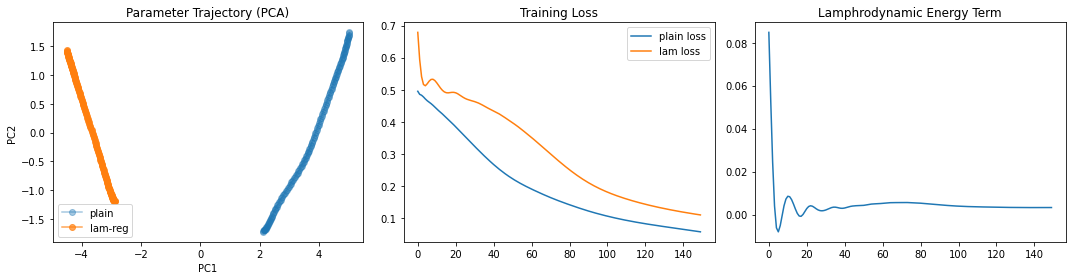

In [4]:
# ----------------------------------------------------------
# PCA of parameter trajectories
# ----------------------------------------------------------
from sklearn.decomposition import PCA

all_points = np.concatenate([traj_plain, traj_lam], axis=0)
p = PCA(n_components=2).fit(all_points)

plain_2d = p.transform(traj_plain)
lam_2d   = p.transform(traj_lam)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
plt.figure(figsize=(15, 4))

# --- (1) PCA trajectories ---
plt.subplot(1, 3, 1)
plt.plot(plain_2d[:,0], plain_2d[:,1], '-o', alpha=0.4, label='plain')
plt.plot(lam_2d[:,0], lam_2d[:,1], '-o', alpha=0.7, label='lam-reg')
plt.title("Parameter Trajectory (PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()

# --- (2) Loss curves ---
plt.subplot(1, 3, 2)
plt.plot(loss_plain, label="plain loss")
plt.plot(loss_lam, label="lam loss")
plt.title("Training Loss")
plt.legend()

# --- (3) Lam Energy ---
plt.subplot(1, 3, 3)
plt.plot(lam_energy)
plt.title("Lamphrodynamic Energy Term")

plt.tight_layout()
plt.show()
